In [232]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [233]:
df = pd.read_csv('/Users/vijaypatidar/vijay/Anshul/deliver time prediction/Food-Delivery-Time-Prediction/data/Food_Delivery_Data.csv')
df.sample(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
37242,0xdaeb,LUDHRES19DEL01,20.0,4.8,30.902872,75.826808,30.942872,75.866808,17-02-2022,16:46:25,17:03:13,conditions Sandstorms,Medium,2,Snack,motorcycle,0.0,No,Metropolitian,(min) 21
9132,0x9255,INDORES19DEL02,36.0,4.7,22.745536,75.893106,22.795536,75.943106,09-03-2022,22:58:17,23:09:32,conditions Cloudy,Low,2,Drinks,motorcycle,1.0,No,Metropolitian,(min) 15


In [234]:
df.shape

(41953, 20)

In [235]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [236]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [237]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41048.000000
mean,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,1.022716,0.745249
std,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,0.838893,0.572152
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000


In [238]:
df.describe(include="object")

,ID,Delivery_person_ID,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City,Time_taken(min)
count,41953,41953,41953,40353,41953,41953,41953,41953,41953,41953,41953,41953
unique,41953,1170,44,25569,26949,7,5,4,4,3,4,45
top,0x4607,JAPRES11DEL02,15-03-2022,19:56:41,21:56:46,conditions Fog,Low,Snack,motorcycle,No,Metropolitian,(min) 26
freq,1,67,1115,8,8,7012,14200,10616,24396,40916,31411,1960


In [239]:
# Missing values count
missing_values = df.isnull().sum()
missing_values

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [240]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})
missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)
missing_df[missing_df['Missing Count']>0]

,Missing Count,Missing Percentage
Delivery_person_Ratings,1763,4.202322
Delivery_person_Age,1719,4.097442
Time_Orderd,1600,3.813792
multiple_deliveries,905,2.157176


In [241]:
df.nunique().sort_values(ascending=False)

ID                             41953
Time_Order_picked              26949
Time_Orderd                    25569
Delivery_location_latitude      4362
Delivery_location_longitude     4362
Delivery_person_ID              1170
Restaurant_latitude              388
Restaurant_longitude             388
Time_taken(min)                   45
Order_Date                        44
Delivery_person_Ratings           28
Delivery_person_Age               22
Weatherconditions                  7
Road_traffic_density               5
Vehicle_condition                  4
Type_of_order                      4
Type_of_vehicle                    4
multiple_deliveries                4
City                               4
Festival                           3
dtype: int64

In [242]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:

    print(col)

    print(df[col].astype(str).str.strip().equals(df[col].astype(str)))

ID
False
Delivery_person_ID
False
Order_Date
True
Time_Orderd
True
Time_Order_picked
True
Weatherconditions
True
Road_traffic_density
False
Type_of_order
False
Type_of_vehicle
False
Festival
False
City
False
Time_taken(min)
True


In [243]:
df["Time_taken(min)"].head()

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: object

In [244]:
# df["Time_taken(min)"] = (
#     df["Time_taken(min)"]
#     .str.extract(r"(\d+)")
#     .astype(int)
# )

In [245]:
df.sample(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
6339,0x4665,RANCHIRES19DEL02,29.0,4.9,23.333017,85.317200,23.383017,85.367200,30-03-2022,19:59:45,20:11:04,conditions Cloudy,Jam,1,Buffet,motorcycle,1.0,No,Metropolitian,(min) 22
35086,0x4e80,JAPRES14DEL01,35.0,4.7,26.888420,75.800689,26.898420,75.810689,07-03-2022,12:02:48,12:16:09,conditions Stormy,High,0,Drinks,motorcycle,2.0,No,Metropolitian,(min) 39


In [246]:
# Temporary target conversion for EDA only

target = (
    df["Time_taken(min)"]
    .str.extract(r"(\d+)")
    .astype(int)
)
target.head()

,0
0,24
1,33
2,26
3,21
4,30


In [247]:
df["multiple_deliveries"].value_counts()

1.0    25928
0.0    12952
2.0     1841
3.0      327
Name: multiple_deliveries, dtype: int64

In [248]:
df["Delivery_person_Ratings"].value_counts().sort_index().head()

1.0    35
2.5    18
2.6    20
2.7    21
2.8    17
Name: Delivery_person_Ratings, dtype: int64

In [249]:
df["Road_traffic_density"].value_counts()

Low        14200
Jam        13043
Medium     10084
High        4071
NaN          555
Name: Road_traffic_density, dtype: int64

In [250]:
df["Weatherconditions"].value_counts()

conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: Weatherconditions, dtype: int64

In [251]:
df_eda = df.copy()
df_eda["Time_taken(min)"] = (
    df_eda["Time_taken(min)"]
    .str.extract(r"(\d+)")
    .astype(int)
)
df_eda.sample(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
20706,0x9328,HYDRES12DEL03,24.0,4.1,17.429585,78.392621,17.459585,78.422621,11-03-2022,20:49:01,21:03:26,conditions Sunny,Jam,0,Buffet,motorcycle,2.0,No,Metropolitian,49
9687,0xc8dc,GOARES13DEL02,20.0,4.6,15.506205,73.766668,15.526205,73.786668,17-02-2022,9:02:51,9:10:49,conditions Windy,Low,2,Snack,scooter,0.0,No,Metropolitian,17


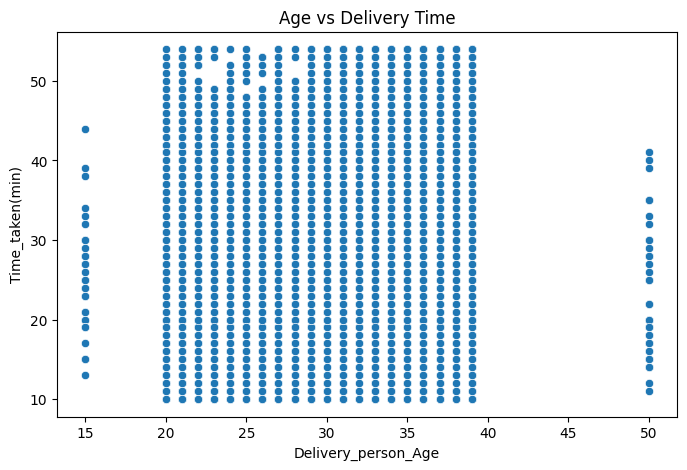

In [252]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_eda,
    x="Delivery_person_Age",
    y="Time_taken(min)"
)
plt.title("Age vs Delivery Time")
plt.show()

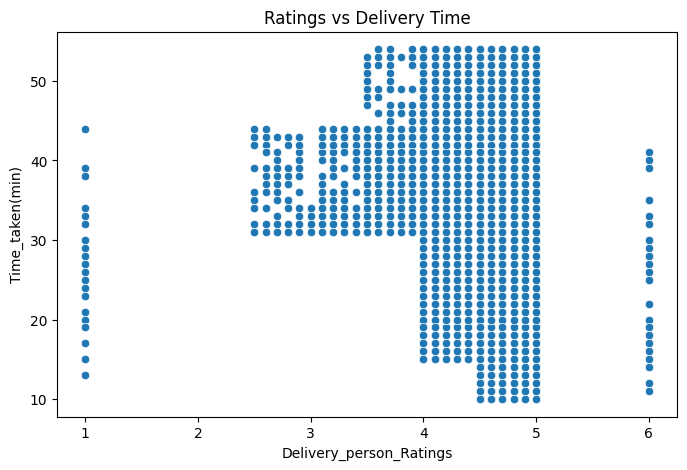

In [253]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_eda,
    x="Delivery_person_Ratings",
    y="Time_taken(min)"
)
plt.title("Ratings vs Delivery Time")
plt.show()

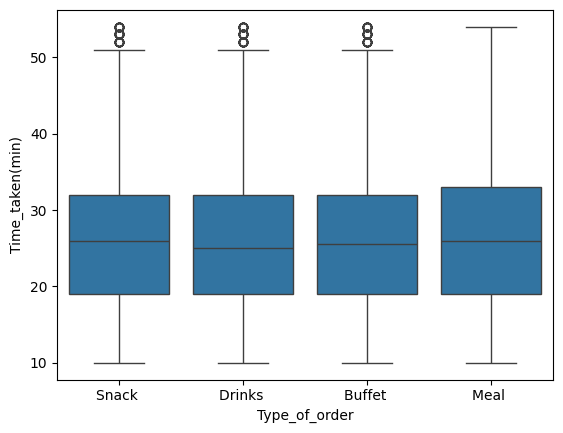

In [254]:
sns.boxplot(
    data=df_eda,
    x="Type_of_order",
    y="Time_taken(min)"
)
plt.show()

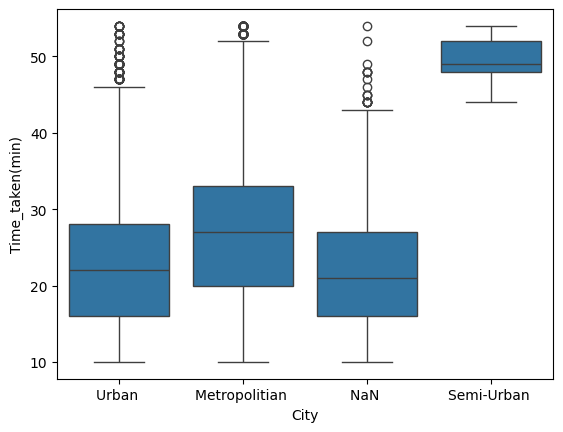

In [255]:
sns.boxplot(
    data=df_eda,
    x="City",
    y="Time_taken(min)"
)
plt.show()

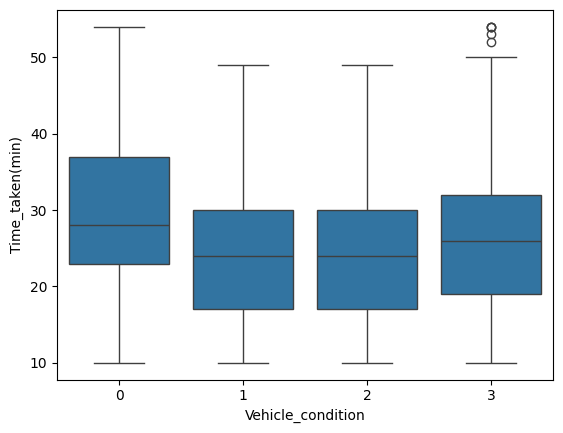

In [256]:
sns.boxplot(
    data=df_eda,
    x="Vehicle_condition",
    y="Time_taken(min)"
)
plt.show()

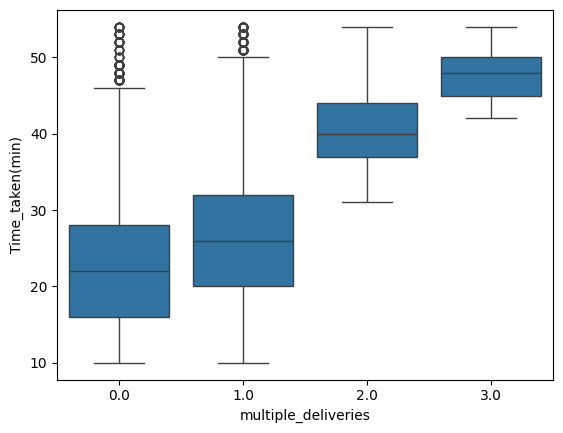

In [257]:
sns.boxplot(
    data=df_eda,
    x="multiple_deliveries",
    y="Time_taken(min)"
)
plt.show()

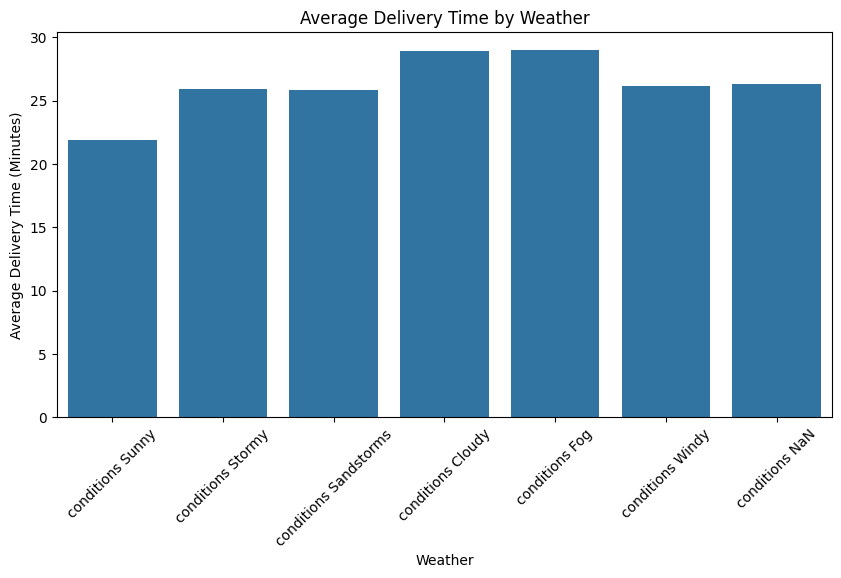

In [258]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_eda,
    x="Weatherconditions",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None
)
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(rotation=45)

plt.show()

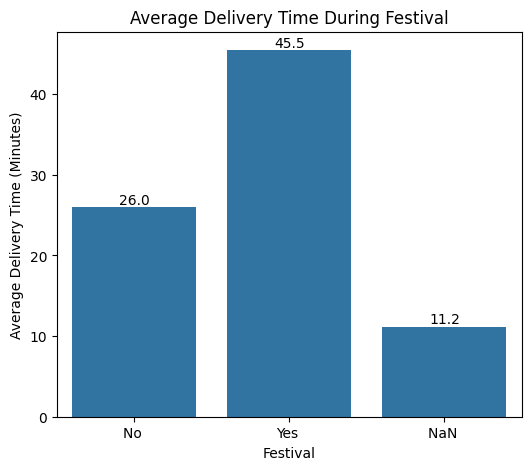

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=df_eda,
    x="Festival",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.title("Average Delivery Time During Festival")
plt.xlabel("Festival")
plt.ylabel("Average Delivery Time (Minutes)")
plt.show()

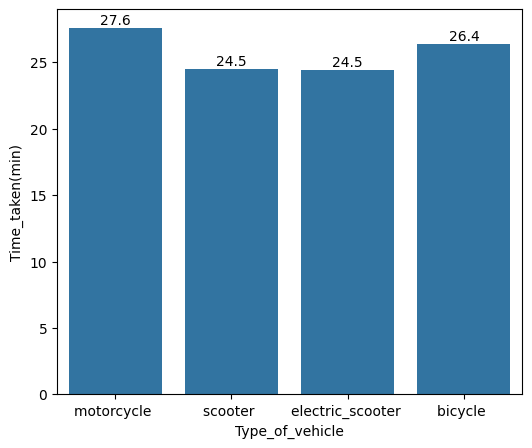

In [260]:
plt.figure(figsize=(6,5))
ax=sns.barplot(
  data=df_eda,
  x='Type_of_vehicle',
  y='Time_taken(min)',
  estimator='mean',
  errorbar=None
)
for container in ax.containers:
  ax.bar_label(container,fmt='%.1f')

In [261]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [262]:
df[["Order_Date", "Time_Orderd", "Time_Order_picked"]].sample(5)

,Order_Date,Time_Orderd,Time_Order_picked
39765,12-02-2022,0:01:30,0:09:13
7801,19-03-2022,21:12:09,21:22:57
31030,02-03-2022,22:24:27,22:34:31
25934,14-02-2022,17:49:01,17:52:50
14076,01-04-2022,17:33:22,17:49:39


In [263]:
df_time = df.copy()
df_time["Order_Date"] = pd.to_datetime(
    df_time["Order_Date"],
    dayfirst=True,
    errors="coerce"
)

In [264]:
df_time["Time_Orderd"] = pd.to_datetime(
    df_time["Time_Orderd"],
    format="%H:%M:%S",
    errors="coerce"
)

df_time["Time_Order_picked"] = pd.to_datetime(
    df_time["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

In [265]:
df_time["Order_Hour"]=df_time["Time_Orderd"].dt.hour

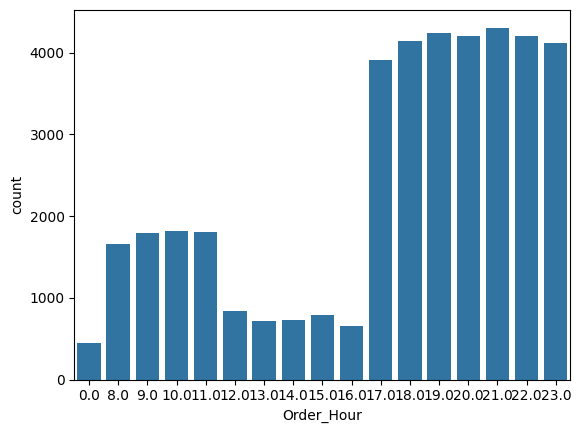

In [266]:
sns.countplot(data=df_time, x="Order_Hour")
plt.show()

In [267]:
df_time["Month"] = df_time["Order_Date"].dt.month
df_time["Day_of_Week"] = df_time["Order_Date"].dt.day_name()

In [268]:
df_time["Weekend"] = df_time["Day_of_Week"].isin(
    ["Saturday", "Sunday"]
)

In [269]:
def rush_hour(hour):
    if 7 <= hour <= 10:
        return "Breakfast"
    elif 12 <= hour <= 15:
        return "Lunch"
    elif 18 <= hour <= 22:
        return "Dinner"
    return "Normal"

df_time["Rush_Hour"] = df_time["Order_Hour"].apply(rush_hour)

In [270]:
df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
27749,0xbbdb,MYSRES08DEL01,34.0,5.0,12.297954,76.665169,12.337954,76.705169,03-04-2022,16:34:01,16:39:37,conditions Fog,Medium,2,Snack,electric_scooter,1.0,No,Metropolitian,(min) 17
28680,0x407f,SURRES01DEL02,33.0,5.0,21.186438,72.794115,21.206438,72.814115,11-03-2022,10:51:19,10:55:36,conditions Sunny,Low,2,Meal,scooter,1.0,No,Urban,(min) 16
18337,0xc729,LUDHRES20DEL02,33.0,3.6,30.885915,75.788259,31.015915,75.918259,12-02-2022,19:38:58,19:53:53,conditions Stormy,Jam,1,Drinks,motorcycle,2.0,No,Metropolitian,(min) 36
31003,0x1c80,SURRES03DEL02,28.0,4.8,21.186884,72.793616,21.266884,72.873616,06-03-2022,18:38:47,18:41:15,conditions Sunny,Medium,1,Snack,motorcycle,1.0,No,Urban,(min) 17
35535,0xd186,ALHRES20DEL01,25.0,5.0,25.454697,81.834492,25.564697,81.944492,12-02-2022,17:48:26,17:58:45,conditions Sandstorms,Medium,1,Meal,scooter,1.0,No,Metropolitian,(min) 26


In [271]:
df_time.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Month,Day_of_Week,Weekend,Rush_Hour
24249,0xaa9e,CHENRES09DEL01,21.0,4.5,13.044694,80.261470,13.154694,80.371470,2022-03-25,1900-01-01 21:21:03,...,motorcycle,1.0,No,Urban,(min) 25,21.0,3,Friday,False,Dinner
3788,0xa173,MUMRES15DEL01,24.0,4.2,19.176269,72.836721,19.246269,72.906721,2022-04-04,1900-01-01 19:53:20,...,motorcycle,0.0,No,Metropolitian,(min) 31,19.0,4,Monday,False,Dinner
6680,0xb459,PUNERES20DEL01,23.0,4.7,18.592718,73.773572,18.602718,73.783572,2022-03-21,1900-01-01 11:48:55,...,motorcycle,0.0,No,Urban,(min) 13,11.0,3,Monday,False,Normal
177,0x57fa,CHENRES04DEL02,35.0,4.7,13.029780,80.208812,13.109780,80.288812,2022-04-06,1900-01-01 20:02:27,...,electric_scooter,1.0,No,Metropolitian,(min) 27,20.0,4,Wednesday,False,Dinner
21477,0x7f9c,BANGRES15DEL02,20.0,4.6,12.975377,77.696664,12.995377,77.716664,2022-03-01,1900-01-01 10:05:39,...,motorcycle,0.0,No,Metropolitian,(min) 13,10.0,3,Tuesday,False,Breakfast


In [272]:
from math import radians, sin, cos, sqrt, atan2

In [273]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat/2)**2
        + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    )

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

In [274]:
df_geo = df.copy()

df_geo["Distance"] = df_geo.apply(
    lambda row: haversine(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

In [275]:
df_geo["Distance"].describe()

count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: Distance, dtype: float64

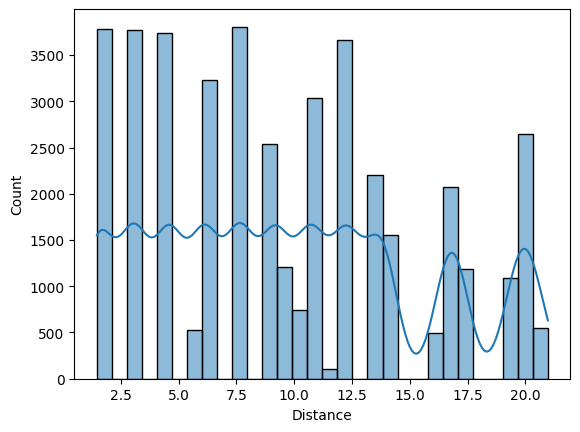

In [276]:
sns.histplot(df_geo["Distance"], bins=30, kde=True)
plt.show()

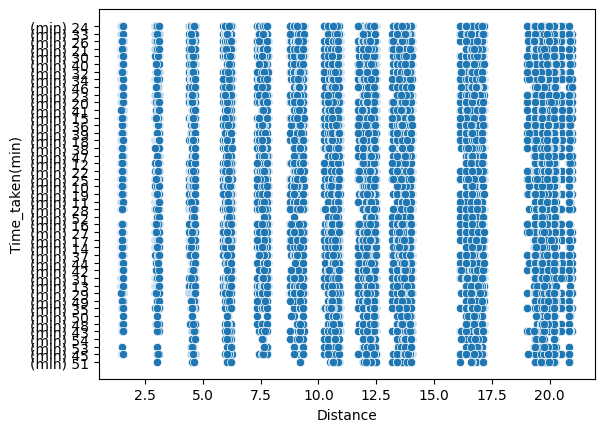

In [277]:
sns.scatterplot(
    data=df_geo,
    x="Distance",
    y="Time_taken(min)"
)
plt.show()

In [278]:
df_geo[
    ["Distance", "Time_taken(min)"]
].corr()


df_geo["Time_taken(min)"] = (
    df_geo["Time_taken(min)"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

In [279]:
eda_corr = df.copy()

eda_corr["Time_taken(min)"] = (
    eda_corr["Time_taken(min)"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

In [280]:
eda_corr["Distance"] = df_geo["Distance"]

In [281]:
corr = eda_corr.select_dtypes(include="number").corr()
corr

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min),Distance
Delivery_person_Age,1.000000,-0.069706,0.005910,0.011163,0.005900,0.011151,0.000849,0.116682,0.298550,-0.001368
Delivery_person_Ratings,-0.069706,1.000000,0.000097,0.003752,-0.000591,0.002676,0.033633,-0.117214,-0.341055,-0.102597
Restaurant_latitude,0.005910,0.000097,1.000000,0.004645,0.999977,0.005120,0.000256,0.010515,0.012185,0.017533
Restaurant_longitude,0.011163,0.003752,0.004645,1.000000,0.004638,0.999945,0.003897,0.008958,0.006680,-0.001506
Delivery_location_latitude,0.005900,-0.000591,0.999977,0.004638,1.000000,0.005183,0.000316,0.011345,0.014335,0.024245
Delivery_location_longitude,0.011151,0.002676,0.005120,0.999945,0.005183,1.000000,0.003991,0.010260,0.010042,0.008983
Vehicle_condition,0.000849,0.033633,0.000256,0.003897,0.000316,0.003991,1.000000,-0.098850,-0.235016,0.009025
multiple_deliveries,0.116682,-0.117214,0.010515,0.008958,0.011345,0.010260,-0.098850,1.000000,0.386747,0.123810
Time_taken(min),0.298550,-0.341055,0.012185,0.006680,0.014335,0.010042,-0.235016,0.386747,1.000000,0.320539
Distance,-0.001368,-0.102597,0.017533,-0.001506,0.024245,0.008983,0.009025,0.123810,0.320539,1.000000


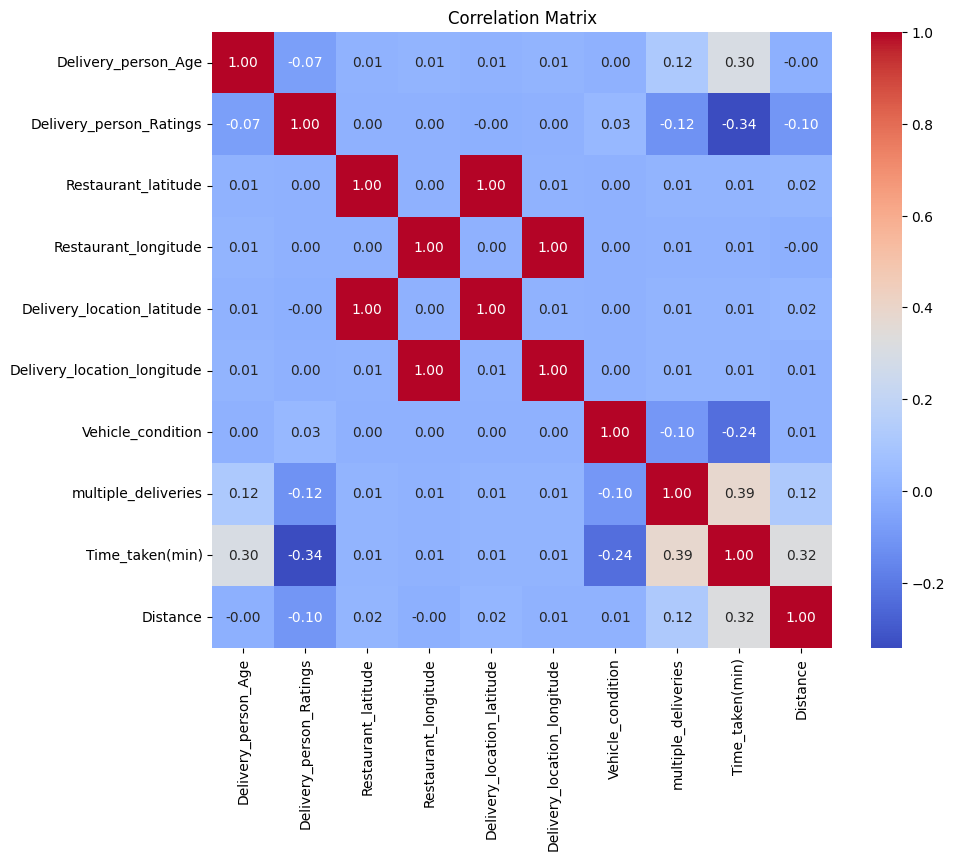

In [282]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [283]:
corr["Time_taken(min)"].sort_values(ascending=False)

Time_taken(min)                1.000000
multiple_deliveries            0.386747
Distance                       0.320539
Delivery_person_Age            0.298550
Delivery_location_latitude     0.014335
Restaurant_latitude            0.012185
Delivery_location_longitude    0.010042
Restaurant_longitude           0.006680
Vehicle_condition             -0.235016
Delivery_person_Ratings       -0.341055
Name: Time_taken(min), dtype: float64

In [284]:
numerical_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Distance",
    "Time_taken(min)"
]

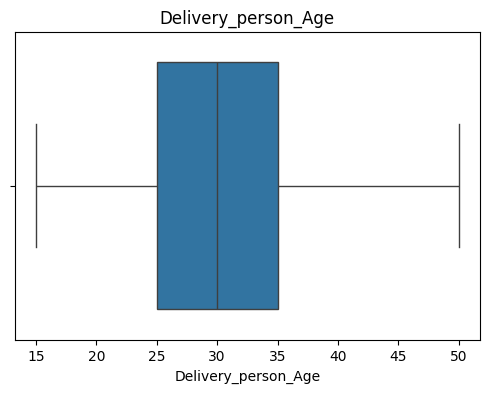

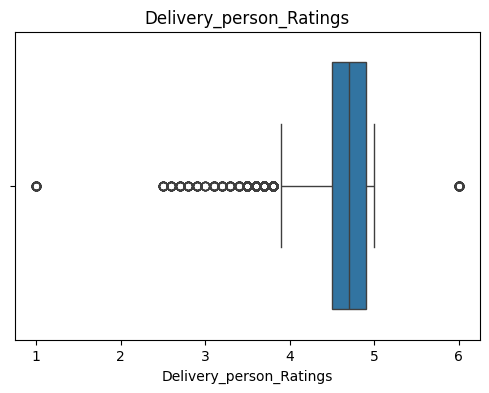

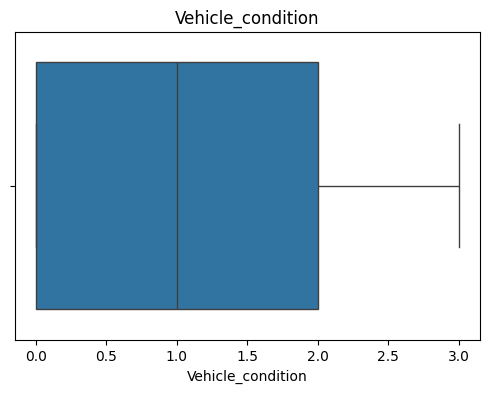

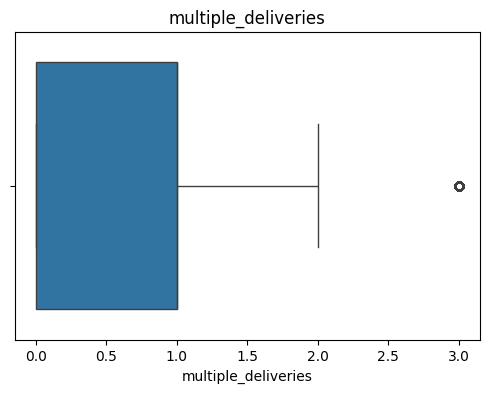

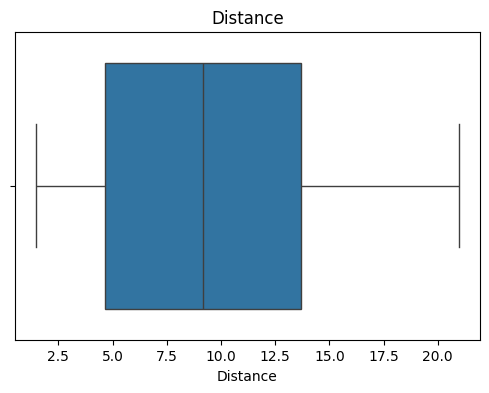

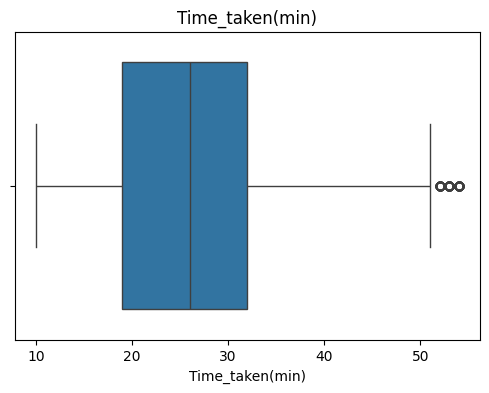

In [285]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_geo[col])
    plt.title(col)
    plt.show()

In [286]:
def detect_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}")
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers : {len(outliers)}")
    print("-"*40)

In [287]:
for col in numerical_cols:
    detect_outliers(df_geo,col)

Delivery_person_Age
Lower Bound : 10.00
Upper Bound : 50.00
Outliers : 0
----------------------------------------
Delivery_person_Ratings
Lower Bound : 3.90
Upper Bound : 5.50
Outliers : 1141
----------------------------------------
Vehicle_condition
Lower Bound : -3.00
Upper Bound : 5.00
Outliers : 0
----------------------------------------
multiple_deliveries
Lower Bound : -1.50
Upper Bound : 2.50
Outliers : 327
----------------------------------------
Distance
Lower Bound : -8.88
Upper Bound : 27.22
Outliers : 0
----------------------------------------
Time_taken(min)
Lower Bound : -0.50
Upper Bound : 51.50
Outliers : 247
----------------------------------------
